# DBSCAN

## Overview

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups points based on local density rather than distance to a centroid. Unlike K-Means, DBSCAN:

- Does **not** require specifying the number of clusters in advance.
- Can discover clusters of **arbitrary shape**.
- Explicitly identifies **outliers** as noise points.

These properties make DBSCAN particularly effective for spatial data, anomaly detection, and any setting where clusters are non-convex or vary in density.

---

## Core Concepts

Every point is classified as one of three types based on two parameters — **eps** ($\varepsilon$) and **min_samples**:

| Point Type | Definition |
|---|---|
| **Core point** | Has $\geq$ `min_samples` points within distance $\varepsilon$ (including itself) |
| **Border point** | Within $\varepsilon$ of a core point, but not itself a core point |
| **Noise point** | Not within $\varepsilon$ of any core point — labeled $-1$ |

---

## Algorithm

**1. For each unvisited point $p$:**
- Find all points within $\varepsilon$: the **$\varepsilon$-neighborhood** $N_\varepsilon(p)$.

**2. If $|N_\varepsilon(p)| < $ `min_samples`:**
- Mark $p$ as noise (temporarily).

**3. Otherwise — $p$ is a core point:**
- Create a new cluster and expand it via BFS:
  - Add all points in $N_\varepsilon(p)$ to the cluster.
  - For each new core point found, recursively add its neighborhood.
  - Border points are absorbed but do not expand the cluster further.

**4. Repeat** until all points are visited.

---

## Density Reachability

Two points are **density-connected** if they are both reachable from a common core point via a chain of $\varepsilon$-neighborhoods:

$$p \xrightarrow{\varepsilon\text{-reach}} q_1 \xrightarrow{\varepsilon\text{-reach}} q_2 \xrightarrow{\varepsilon\text{-reach}} \cdots \xrightarrow{\varepsilon\text{-reach}} q$$

All density-connected points form one cluster.

---

## Choosing eps and min_samples

- **`eps`** — use a **k-distance plot**: sort the distance to the $k$-th nearest neighbor for all points. The "elbow" in this plot is a good estimate for `eps`.
- **`min_samples`** — a common heuristic is `min_samples` $\geq$ `n_features + 1`. Higher values produce denser, more conservative clusters.

---

## DBSCAN vs K-Means

| | DBSCAN | K-Means |
|---|---|---|
| **k required** | No | Yes |
| **Cluster shape** | Arbitrary | Convex/spherical |
| **Outliers** | Explicit noise label | Forced into a cluster |
| **Scalability** | $O(n^2)$ naïve | $O(n \cdot k)$ per iter |
| **Sensitivity** | eps, min_samples | k, initialization |

 EXPERIMENT 1 — DBSCAN vs K-Means (Moons & Circles)


C:\Users\HP\AppData\Local\Temp\ipykernel_16492\1228817340.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique) - (1 if -1 in unique else 0)))
C:\Users\HP\AppData\Local\Temp\ipykernel_16492\1228817340.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique) - (1 if -1 in unique else 0)))


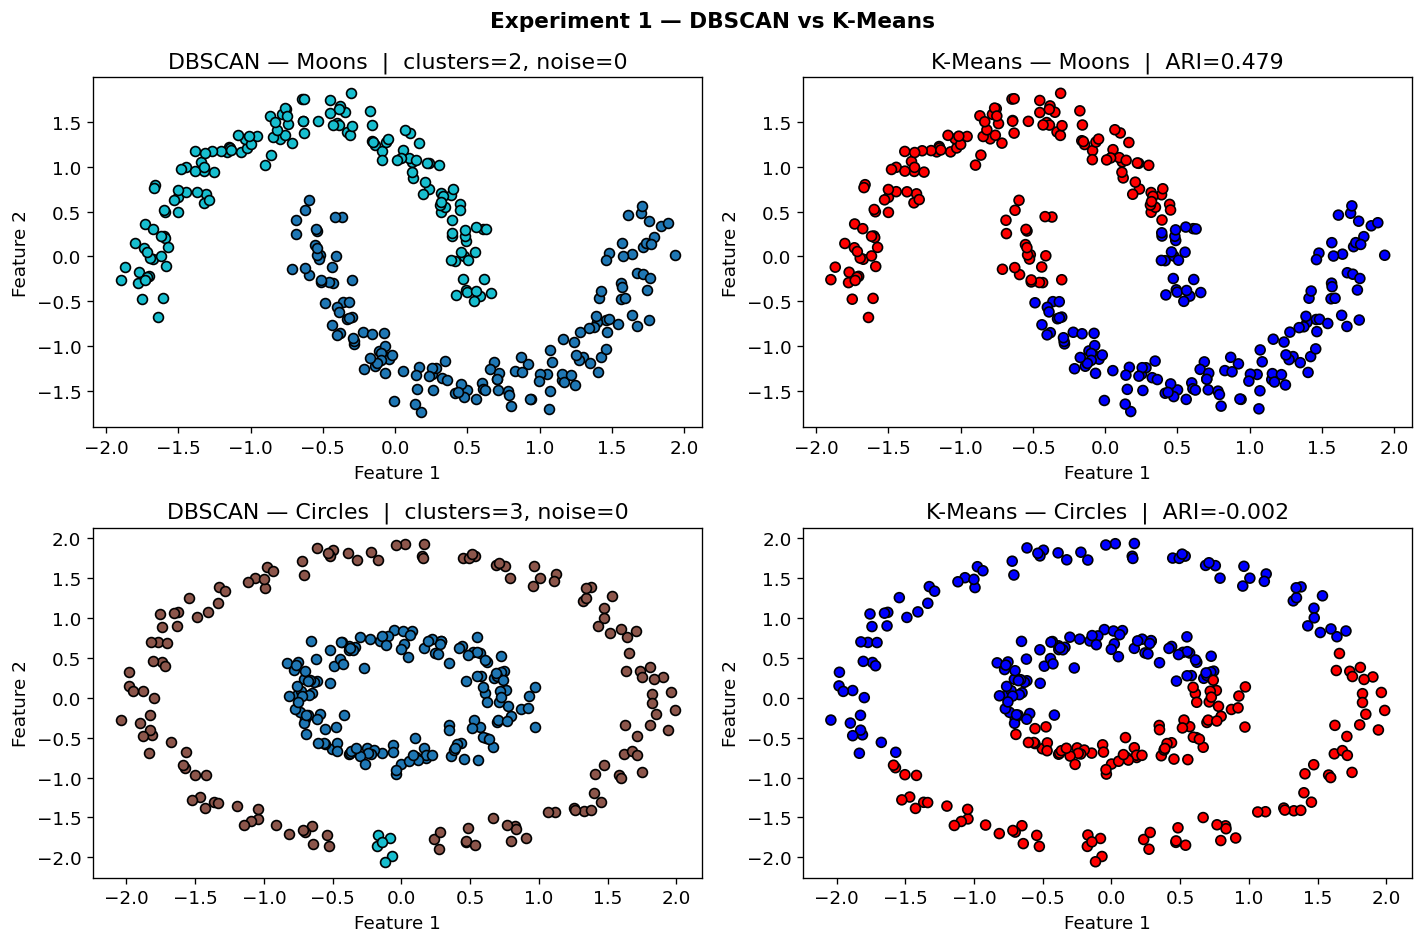

 EXPERIMENT 2 — K-Distance Plot (Choosing eps)


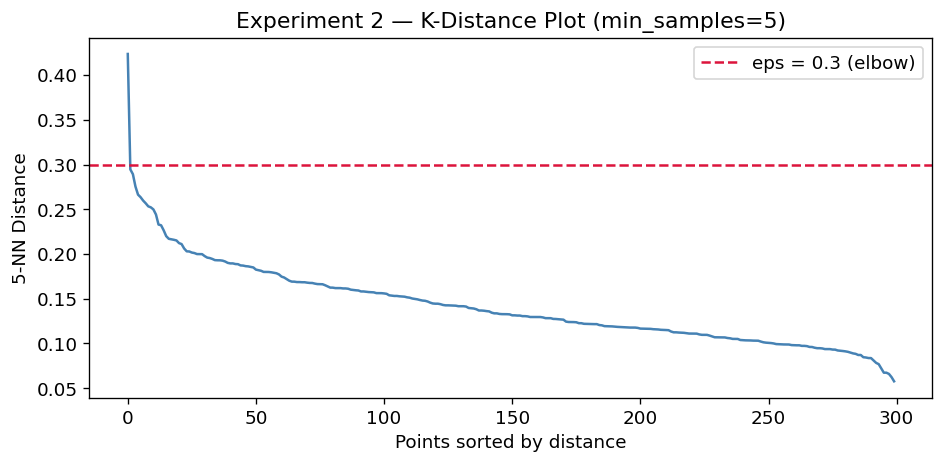

 EXPERIMENT 3 — Effect of eps and min_samples


C:\Users\HP\AppData\Local\Temp\ipykernel_16492\1228817340.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique) - (1 if -1 in unique else 0)))


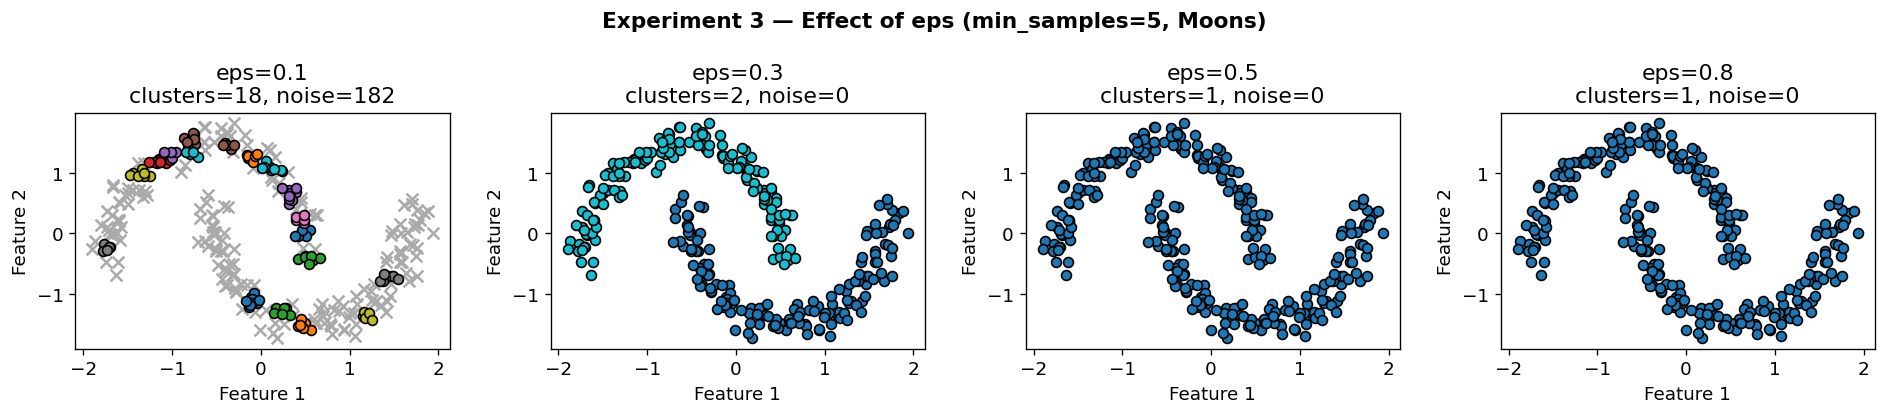

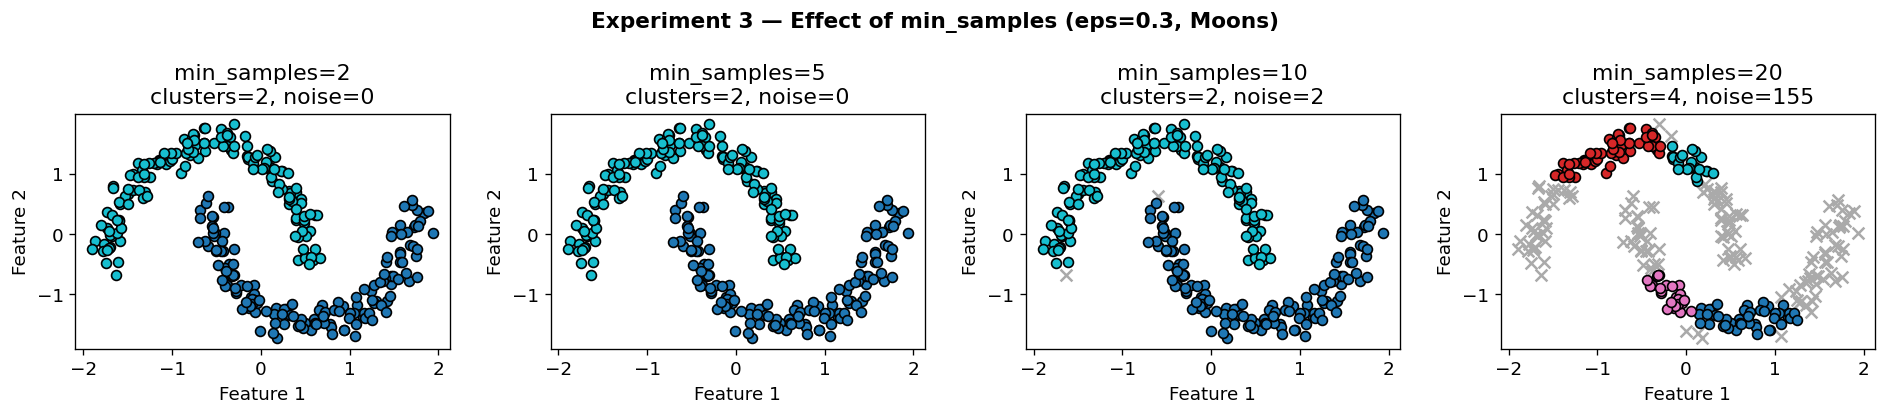

 EXPERIMENT 4 — Blobs with Injected Outliers


C:\Users\HP\AppData\Local\Temp\ipykernel_16492\1228817340.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique) - (1 if -1 in unique else 0)))


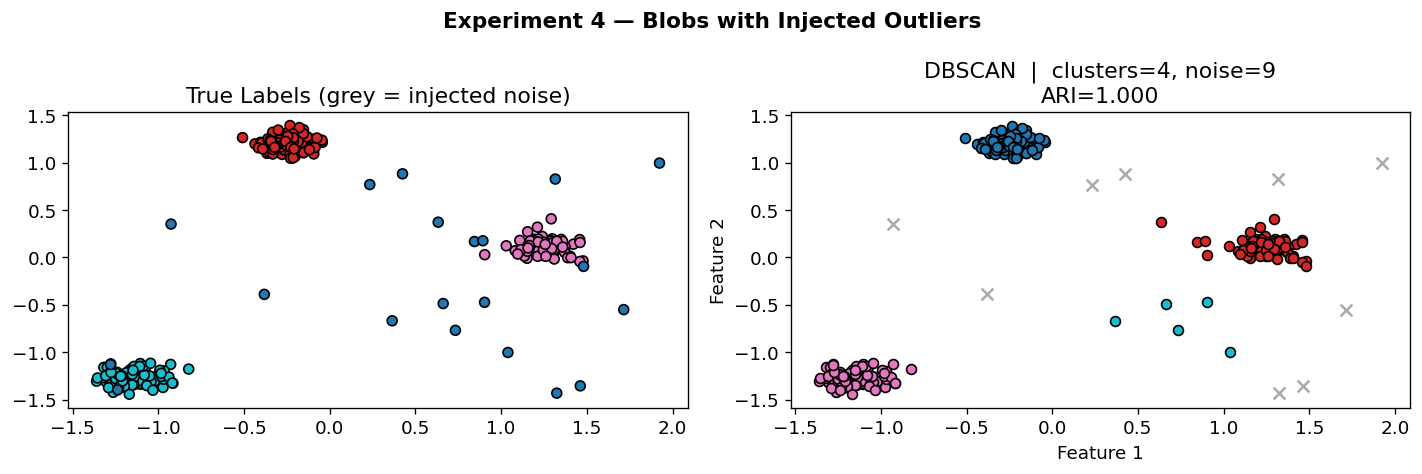

Clusters found : 4
Noise points   : 9
ARI (blobs)    : 1.0000



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, silhouette_score
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.unsupervised_learning.dbscan import DBSCAN
from mlpackage.unsupervised_learning.kmeans import KMeans

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

NOISE_COLOR = "#aaaaaa"

def plot_dbscan(X, labels, ax, title):
    unique = sorted(set(labels))
    cmap = plt.cm.get_cmap("tab10", max(1, len(unique) - (1 if -1 in unique else 0)))
    color_idx = 0
    for lbl in unique:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c=NOISE_COLOR,
                       marker="x", s=50, label="Noise", zorder=3)
        else:
            ax.scatter(X[mask, 0], X[mask, 1], color=cmap(color_idx),
                       edgecolors="k", s=35, label=f"Cluster {lbl}", zorder=3)
            color_idx += 1
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. DBSCAN vs K-Means on Non-Spherical Data ───────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — DBSCAN vs K-Means (Moons & Circles)")
print("=" * 55)

datasets = {
    "Moons":   make_moons(n_samples=300, noise=0.07, random_state=42),
    "Circles": make_circles(n_samples=300, noise=0.05, factor=0.4, random_state=42),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (name, (X_ds, y_ds)) in enumerate(datasets.items()):
    X_s = StandardScaler().fit_transform(X_ds)
    db  = DBSCAN(eps=0.3, min_samples=5)
    km  = KMeans(k=2, random_state=42)
    db.fit(X_s)
    km.fit(X_s)

    plot_dbscan(X_s, db.labels_, axes[row, 0],
        f"DBSCAN — {name}  |  clusters={db.n_clusters_}, noise={db.n_noise_}")
    axes[row, 1].scatter(X_s[:, 0], X_s[:, 1], c=km.labels_,
                         cmap="bwr", edgecolors="k", s=35)
    axes[row, 1].set_title(f"K-Means — {name}  |  ARI={adjusted_rand_score(y_ds, km.labels_):.3f}")
    axes[row, 1].set_xlabel("Feature 1"); axes[row, 1].set_ylabel("Feature 2")

plt.suptitle("Experiment 1 — DBSCAN vs K-Means", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 2. K-Distance Plot — Choosing eps ────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — K-Distance Plot (Choosing eps)")
print("=" * 55)

X_moon, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
X_moon = StandardScaler().fit_transform(X_moon)

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_moon)
distances, _ = nbrs.kneighbors(X_moon)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, color="steelblue")
ax.axhline(0.3, color="crimson", linestyle="--", label="eps = 0.3 (elbow)")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"{min_samples}-NN Distance")
ax.set_title(f"Experiment 2 — K-Distance Plot (min_samples={min_samples})")
ax.legend()
plt.tight_layout()
plt.show()


# ── 3. Effect of eps and min_samples ─────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Effect of eps and min_samples")
print("=" * 55)

eps_vals = [0.1, 0.3, 0.5, 0.8]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, eps in zip(axes, eps_vals):
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(X_moon)
    plot_dbscan(X_moon, db.labels_, ax,
        f"eps={eps}\nclusters={db.n_clusters_}, noise={db.n_noise_}")

plt.suptitle("Experiment 3 — Effect of eps (min_samples=5, Moons)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

min_vals = [2, 5, 10, 20]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, ms in zip(axes, min_vals):
    db = DBSCAN(eps=0.3, min_samples=ms)
    db.fit(X_moon)
    plot_dbscan(X_moon, db.labels_, ax,
        f"min_samples={ms}\nclusters={db.n_clusters_}, noise={db.n_noise_}")

plt.suptitle("Experiment 3 — Effect of min_samples (eps=0.3, Moons)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 4. Blobs with Outliers ────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Blobs with Injected Outliers")
print("=" * 55)

X_blobs, y_blobs = make_blobs(n_samples=250, centers=3,
                               cluster_std=0.5, random_state=42)
rng = np.random.default_rng(0)
noise_pts = rng.uniform(-8, 8, size=(20, 2))
X_with_noise = np.vstack([X_blobs, noise_pts])
y_with_noise  = np.concatenate([y_blobs, [-1]*20])
X_with_noise  = StandardScaler().fit_transform(X_with_noise)

db_blobs = DBSCAN(eps=0.4, min_samples=5)
db_blobs.fit(X_with_noise)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_with_noise[:, 0], X_with_noise[:, 1],
                c=y_with_noise, cmap="tab10", edgecolors="k", s=35)
axes[0].set_title("True Labels (grey = injected noise)")

plot_dbscan(X_with_noise, db_blobs.labels_, axes[1],
    f"DBSCAN  |  clusters={db_blobs.n_clusters_}, noise={db_blobs.n_noise_}\n"
    f"ARI={adjusted_rand_score(y_blobs, db_blobs.labels_[:250]):.3f}")

plt.suptitle("Experiment 4 — Blobs with Injected Outliers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Clusters found : {db_blobs.n_clusters_}")
print(f"Noise points   : {db_blobs.n_noise_}")
print(f"ARI (blobs)    : {adjusted_rand_score(y_blobs, db_blobs.labels_[:250]):.4f}\n")